[Reference](https://medium.com/@Rohan_Dutt/10-hybrid-forecasting-architectures-blending-deep-learning-with-time-series-models-252c685601e1)

# 1. Temporal Fusion Transformers (TFT) for Multivariate Forecasting

In [16]:
import torch
import torch.nn as nn
import numpy as np


class TemporalFusionTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config
        self.quantiles = config["quantiles"]

        self.temporal_input_dim = config["input_dim"]
        self.fused_input_dim = config["input_dim"] + config["static_dim"]

        # Static covariate encoder
        self.static_embedding = nn.Embedding(
            num_embeddings=config["n_static_categories"],
            embedding_dim=config["static_dim"]
        )

        # Variable selection network
        self.temporal_selector = nn.Sequential(
            nn.Linear(self.fused_input_dim, config["hidden_dim"]),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(config["hidden_dim"], self.fused_input_dim),
            nn.Sigmoid()
        )

        # LSTM encoder
        self.lstm_encoder = nn.LSTM(
            input_size=self.fused_input_dim,
            hidden_size=config["hidden_dim"],
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        # Multi-head attention
        self.attention = nn.MultiheadAttention(
            embed_dim=config["hidden_dim"],
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )

        # ModuleDict key에 "."이 들어가면 안 되므로 q10, q50, q90 형태 사용
        self.quantile_keys = {
            q: f"q{int(q * 100)}"
            for q in self.quantiles
        }

        self.quantile_forecast_head = nn.ModuleDict({
            self.quantile_keys[q]: nn.Linear(config["hidden_dim"], 1)
            for q in self.quantiles
        })

    def forward(self, x, static_covariates, future_steps=24):
        """
        x: [batch, history_len, features]
        static_covariates: [batch, 1] 또는 [batch]
        """

        # [batch, 1] -> [batch]
        static_covariates = static_covariates.squeeze(-1)

        # [batch, static_dim]
        static_emb = self.static_embedding(static_covariates)

        # [batch, history_len, static_dim]
        static_emb = static_emb.unsqueeze(1).expand(-1, x.size(1), -1)

        # [batch, history_len, input_dim + static_dim]
        fused_input = torch.cat([x, static_emb], dim=-1)

        # Variable selection
        importance_weights = self.temporal_selector(fused_input)
        selected_features = fused_input * importance_weights

        # LSTM
        lstm_out, _ = self.lstm_encoder(selected_features)

        # Self-attention
        attn_out, attn_weights = self.attention(
            lstm_out,
            lstm_out,
            lstm_out
        )

        # Forecast from last future_steps positions
        predictions = {}

        for q in self.quantiles:
            key = self.quantile_keys[q]
            predictions[q] = self.quantile_forecast_head[key](
                attn_out[:, -future_steps:, :]
            )

        return predictions, importance_weights, attn_weights


config = {
    "n_static_categories": 50,
    "static_dim": 16,
    "input_dim": 32,
    "hidden_dim": 128,
    "quantiles": [0.1, 0.5, 0.9]
}

batch_size, history_len, features = 64, 168, 32

temporal_data = torch.randn(batch_size, history_len, features)
static_data = torch.randint(0, 50, (batch_size, 1))

model = TemporalFusionTransformer(config)

quantile_preds, feature_importance, attention_map = model(
    temporal_data,
    static_data
)

print(quantile_preds.keys())

for q, pred in quantile_preds.items():
    print(f"q={q}, shape={pred.shape}")

avg_feature_importance = feature_importance.mean(dim=1).detach().numpy()

print(f"Top 3 important fused features: {np.argsort(avg_feature_importance)[0, -3:]}")
print(f"attention map shape: {attention_map.shape}")

dict_keys([0.1, 0.5, 0.9])
q=0.1, shape=torch.Size([64, 24, 1])
q=0.5, shape=torch.Size([64, 24, 1])
q=0.9, shape=torch.Size([64, 24, 1])
Top 3 important fused features: [43 41 12]
attention map shape: torch.Size([64, 168, 168])


# 2. N-BEATS: Interpretable Neural Basis Expansion

Trend std: 0.480, Seasonal std: 0.464


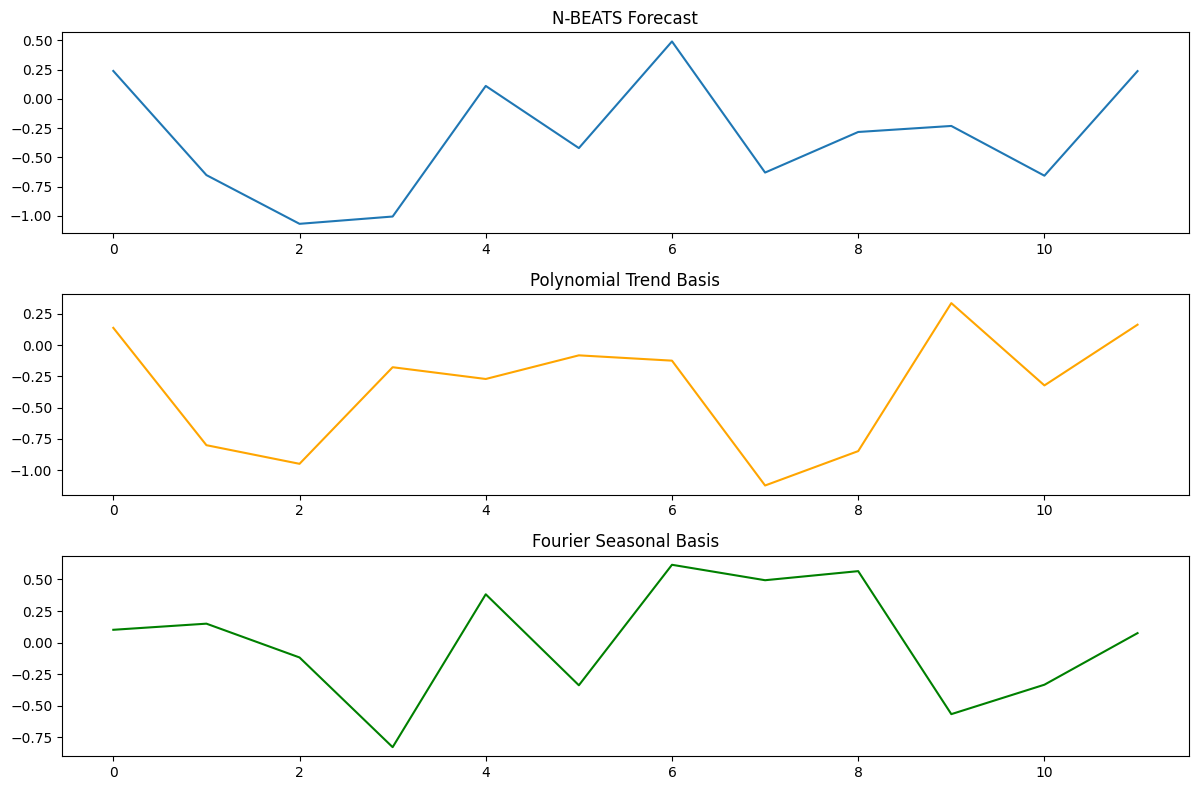

In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class NBEATSBlock(nn.Module):
    def __init__(self, input_len, theta_dim, share_thetas=True):
        super().__init__()
        # 4-layer MLP backbone for feature extraction
        self.backbone = nn.Sequential(
            nn.Linear(input_len, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, theta_dim)
        )

        # Trend basis: polynomial terms
        self.trend_basis = nn.Linear(theta_dim // 2, input_len)

        # Seasonality basis: harmonic functions
        self.seasonality_basis = nn.Linear(theta_dim // 2, input_len)

    def forward(self, x):
        # x: [batch, input_len]
        theta = self.backbone(x)
        theta_trend, theta_seasonal = torch.chunk(theta, 2, dim=1)

        # Generate interpretable components
        trend = self.trend_basis(theta_trend)
        seasonal = self.seasonality_basis(theta_seasonal)

        # Forward forecast (simple linear projection here, can be extended)
        forecast = trend + seasonal

        return forecast, trend, seasonal

class NBEATS(nn.Module):
    def __init__(self, input_len=168, forecast_len=24, n_stacks=30):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBEATSBlock(input_len, theta_dim=64) for _ in range(n_stacks)
        ])
        self.forecast_len = forecast_len

    def forward(self, x):
        """
        Args:
            x: Historical values [batch, history_len]
        Returns:
            Decomposed forecasts for interpretability
        """
        block_forecasts = []
        block_trends = []
        block_seasonals = []

        # Iterative decomposition: each block refines residual
        residual = x
        for block in self.blocks:
            forecast, trend, seasonal = block(residual)
            block_forecasts.append(forecast)
            block_trends.append(trend)
            block_seasonals.append(seasonal)

            # Update residual for next block (different from standard implementation)
            residual = residual - trend[:, :residual.size(1)]

        # Sum all block contributions
        total_forecast = sum(block_forecasts)[:, -self.forecast_len:]
        total_trend = sum(block_trends)[:, -self.forecast_len:]
        total_seasonal = sum(block_seasonals)[:, -self.forecast_len:]

        return {
            'forecast': total_forecast,
            'trend': total_trend,
            'seasonal': total_seasonal
        }

# Train on monthly sales data with strong trend and seasonality
model = NBEATS(input_len=36, forecast_len=12, n_stacks=20)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Synthetic quarterly seasonal pattern with linear trend
history = torch.sin(torch.linspace(0, 8*np.pi, 36)) + torch.linspace(0, 2, 36)
history = history.unsqueeze(0)  # Add batch dimension

# Forward pass
output = model(history)

# Plot interpretable decomposition
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))
ax1.plot(output['forecast'].detach()[0], label='Total Forecast')
ax1.set_title('N-BEATS Forecast')
ax2.plot(output['trend'].detach()[0], label='Trend Component', color='orange')
ax2.set_title('Polynomial Trend Basis')
ax3.plot(output['seasonal'].detach()[0], label='Seasonal Component', color='green')
ax3.set_title('Fourier Seasonal Basis')
plt.tight_layout()
plt.savefig('nbeats_decomposition.png')

# Print component contributions
print(f"Trend std: {output['trend'].std():.3f}, Seasonal std: {output['seasonal'].std():.3f}")

# 3. DeepAR+ with Probabilistic Outputs

In [14]:
import torch
import torch.nn as nn
from torch.distributions import StudentT
import pandas as pd
import numpy as np


class DeepARPlus(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.series_embedding = nn.Embedding(
            config['n_series'],
            config['embed_dim']
        )

        self.lstm = nn.LSTM(
            input_size=config['input_dim'] + config['embed_dim'],
            hidden_size=config['hidden_dim'],
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.loc_head = nn.Linear(config['hidden_dim'], 1)

        self.scale_head = nn.Sequential(
            nn.Linear(config['hidden_dim'], 1),
            nn.Softplus()
        )

        self.df_head = nn.Sequential(
            nn.Linear(config['hidden_dim'], 1),
            nn.Softplus()
        )

    def forward(self, past_values, past_covariates, series_ids):
        """
        past_values: [batch, history_len, 1]
        past_covariates: [batch, history_len, n_covariates]
        series_ids: [batch] or [batch, 1]
        """
        series_ids = series_ids.squeeze(-1)

        series_emb = self.series_embedding(series_ids)       # [batch, embed_dim]
        series_emb = series_emb.unsqueeze(1)                 # [batch, 1, embed_dim]
        series_emb = series_emb.expand(
            -1,
            past_values.size(1),
            -1
        )

        lstm_input = torch.cat(
            [past_values, past_covariates, series_emb],
            dim=-1
        )

        lstm_out, _ = self.lstm(lstm_input)

        loc = self.loc_head(lstm_out)
        scale = self.scale_head(lstm_out) + 1e-6
        df = self.df_head(lstm_out) + 2

        return StudentT(loc=loc, scale=scale, df=df)

    def sample_quantiles(
        self,
        past_data,
        covariates,
        series_ids,
        future_steps,
        quantiles=[0.1, 0.5, 0.9]
    ):
        samples = []

        for _ in range(500):
            with torch.no_grad():
                dist = self.forward(past_data, covariates[:, :past_data.size(1), :], series_ids)

                sample = []

                for step in range(future_steps):
                    step_dist = StudentT(
                        loc=dist.loc[:, -1:, :],
                        scale=dist.scale[:, -1:, :],
                        df=dist.df[:, -1:, :]
                    )

                    next_val = step_dist.sample()            # [batch, 1, 1]
                    sample.append(next_val.squeeze(-1))      # [batch, 1]

                samples.append(torch.cat(sample, dim=1))     # [batch, future_steps]

        samples = torch.stack(samples, dim=0)                 # [n_samples, batch, future_steps]

        q = torch.tensor(
            quantiles,
            device=samples.device,
            dtype=samples.dtype
        )

        quantile_preds = torch.quantile(samples, q, dim=0)

        return quantile_preds


n_series, history_len, n_covariates = 100, 52, 3

config = {
    'n_series': n_series,
    'embed_dim': 16,
    'input_dim': n_covariates + 1,
    'hidden_dim': 64
}

series_data = []

for i in range(n_series):
    seasonal = 10 * np.sin(np.linspace(0, 4 * np.pi, history_len)) * (1 + i * 0.01)
    trend = np.linspace(100, 110, history_len)
    series_data.append(
        seasonal + trend + np.random.normal(0, 2, history_len)
    )

df = pd.DataFrame({
    'series_id': np.repeat(range(n_series), history_len),
    'week': np.tile(range(history_len), n_series),
    'demand': np.concatenate(series_data)
})

model = DeepARPlus(config)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    batch_ids = torch.randint(0, n_series, (32, 1))
    batch_data = torch.randn(32, history_len, 1)
    batch_cov = torch.randn(32, history_len, n_covariates)

    dist = model(batch_data, batch_cov, batch_ids)

    loss = -dist.log_prob(batch_data).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, NLL: {loss.item():.3f}")

past_data = torch.randn(1, history_len, 1)

# sample_quantiles 내부에서는 history_len 길이의 covariates도 필요하므로
# 여기서는 간단히 52주 covariates를 넣습니다.
covariates = torch.randn(1, history_len, n_covariates)

series_id = torch.tensor([[42]])

quantiles = model.sample_quantiles(
    past_data,
    covariates,
    series_id,
    future_steps=24
)

print(
    f"P10: {quantiles[0].mean():.1f}, "
    f"P50: {quantiles[1].mean():.1f}, "
    f"P90: {quantiles[2].mean():.1f}"
)

Epoch 0, NLL: 1.476
Epoch 10, NLL: 1.437
Epoch 20, NLL: 1.445
Epoch 30, NLL: 1.398
Epoch 40, NLL: 1.316
Epoch 50, NLL: 0.996
Epoch 60, NLL: 0.370
Epoch 70, NLL: -0.094
Epoch 80, NLL: -0.291
Epoch 90, NLL: -0.491
P10: 0.2, P50: 0.4, P90: 0.6


# 4. Transformer-XH: Hybrid Attention for Long Horizons


30-day forecast shape: torch.Size([2, 30])
attention matrix shape: torch.Size([2, 3650, 3650])


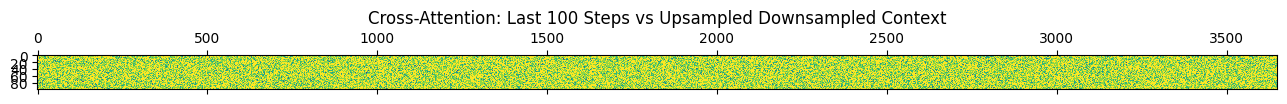

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


class HierarchicalDownsampler(nn.Module):
    def __init__(self, input_dim, downsample_rate=4):
        super().__init__()

        self.input_dim = input_dim
        self.downsample_rate = downsample_rate

        self.wavelet_conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=input_dim * 4,
            kernel_size=downsample_rate,
            stride=downsample_rate,
            groups=input_dim
        )

    def forward(self, x):
        """
        x: [batch, seq_len, features]
        returns: [batch, seq_len // rate, features * 4]
        """
        x = x.permute(0, 2, 1)       # [batch, features, seq_len]
        coeffs = self.wavelet_conv(x)
        return coeffs.permute(0, 2, 1)


class SparseAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, window_size=64):
        super().__init__()

        self.num_heads = num_heads
        self.window_size = window_size

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=0.1,
            batch_first=True
        )

    def forward(self, query, key, value):
        """
        query/key/value: [batch, seq_len, embed_dim]
        """
        batch_size, seq_len, embed_dim = query.shape

        pad_len = (self.window_size - seq_len % self.window_size) % self.window_size

        if pad_len > 0:
            query = F.pad(query, (0, 0, 0, pad_len))
            key = F.pad(key, (0, 0, 0, pad_len))
            value = F.pad(value, (0, 0, 0, pad_len))

        padded_len = query.size(1)
        windows = padded_len // self.window_size

        q = query.reshape(batch_size * windows, self.window_size, embed_dim)
        k = key.reshape(batch_size * windows, self.window_size, embed_dim)
        v = value.reshape(batch_size * windows, self.window_size, embed_dim)

        attn_out, attn_weights = self.attention(q, k, v)

        attn_out = attn_out.reshape(batch_size, padded_len, embed_dim)

        attn_out = attn_out[:, :seq_len, :]

        return attn_out, attn_weights


class TransformerXH(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.input_dim = config["input_dim"]
        self.hidden_dim = config["hidden_dim"]
        self.forecast_len = config["forecast_len"]

        self.downsampler = HierarchicalDownsampler(
            input_dim=config["input_dim"],
            downsample_rate=config["downsample_rate"]
        )

        self.encoder_orig = nn.LSTM(
            input_size=config["input_dim"],
            hidden_size=config["hidden_dim"],
            num_layers=1,
            batch_first=True
        )

        self.encoder_down = nn.LSTM(
            input_size=config["input_dim"] * 4,
            hidden_size=config["hidden_dim"],
            num_layers=1,
            batch_first=True
        )

        self.sparse_attn = SparseAttention(
            embed_dim=config["hidden_dim"],
            num_heads=8,
            window_size=config["window_size"]
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=config["hidden_dim"],
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )

        self.forecast_head = nn.Linear(
            config["hidden_dim"],
            config["forecast_len"]
        )

    def forward(self, x):
        """
        x: [batch, seq_len, features]
        """
        orig_features, _ = self.encoder_orig(x)
        # [batch, seq_len, hidden_dim]

        downsampled = self.downsampler(x)
        # [batch, seq_len // downsample_rate, input_dim * 4]

        down_features, _ = self.encoder_down(downsampled)
        # [batch, down_seq_len, hidden_dim]

        down_features, sparse_weights = self.sparse_attn(
            down_features,
            down_features,
            down_features
        )

        down_upsampled = F.interpolate(
            down_features.transpose(1, 2),
            size=orig_features.size(1),
            mode="linear",
            align_corners=False
        ).transpose(1, 2)

        cross_out, cross_weights = self.cross_attention(
            orig_features,
            down_upsampled,
            down_upsampled
        )

        forecast = self.forecast_head(cross_out[:, -1, :])

        return forecast, cross_weights


config = {
    "input_dim": 5,
    "hidden_dim": 256,
    "downsample_rate": 4,
    "window_size": 128,
    "forecast_len": 30
}

model = TransformerXH(config)

long_sequence = torch.randn(2, 3650, 5)

forecast, attention_matrix = model(long_sequence)

print(f"30-day forecast shape: {forecast.shape}")
print(f"attention matrix shape: {attention_matrix.shape}")

plt.matshow(attention_matrix[0].detach().cpu().numpy()[-100:, :])
plt.title("Cross-Attention: Last 100 Steps vs Upsampled Downsampled Context")
plt.savefig("transformer_xh_attention.png")

# 5. N-HiTS: Neural Hierarchical Interpolation for Time Series

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class NHitsBlock(nn.Module):
    def __init__(self, input_len, forecast_len, n_freqs=8):
        super().__init__()

        self.input_len = input_len
        self.forecast_len = forecast_len
        self.n_freqs = n_freqs

        self.backbone = nn.Sequential(
            nn.Linear(input_len, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, n_freqs * 2)
        )

        frequencies = torch.arange(1, n_freqs + 1).float() * 2 * torch.pi / forecast_len
        self.register_buffer("frequencies", frequencies)

    def forward(self, x):
        """
        x: [batch, history_len]
        returns: list of 4 forecasts, each [batch, forecast_len]
        """
        coeffs = self.backbone(x)  # [batch, n_freqs * 2]

        sine_coeffs, cosine_coeffs = coeffs.chunk(2, dim=1)
        # each: [batch, n_freqs]

        forecasts = []

        for dilation in [1, 2, 4, 8]:
            low_res_horizon = max(1, self.forecast_len // dilation)

            time_steps = torch.arange(
                low_res_horizon,
                device=x.device,
                dtype=x.dtype
            )

            frequencies = self.frequencies.to(dtype=x.dtype)

            # [low_res_horizon, n_freqs]
            angles = time_steps.unsqueeze(1) * frequencies.unsqueeze(0) / dilation

            sine_basis = torch.sin(angles)
            cosine_basis = torch.cos(angles)

            # [batch, low_res_horizon]
            forecast_low_res = (
                sine_coeffs @ sine_basis.T
                + cosine_coeffs @ cosine_basis.T
            )

            # F.interpolate with mode='linear' expects [batch, channels, length]
            forecast = F.interpolate(
                forecast_low_res.unsqueeze(1),
                size=self.forecast_len,
                mode="linear",
                align_corners=False
            ).squeeze(1)

            forecasts.append(forecast)

        return forecasts


class NHiTS(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.input_len = config["input_len"]
        self.forecast_len = config["forecast_len"]

        self.blocks = nn.ModuleList([
            NHitsBlock(
                input_len=self.input_len,
                forecast_len=self.forecast_len
            )
            for _ in range(config["n_blocks"])
        ])

        self.scale_weights = nn.Parameter(
            torch.ones(config["n_blocks"], 4) / 4
        )

    def forward(self, x):
        """
        x: [batch, history_len, features]
        """
        batch_size = x.size(0)

        # univariate
        x = x[:, :, 0]  # [batch, history_len]

        final_forecast = torch.zeros(
            batch_size,
            self.forecast_len,
            device=x.device,
            dtype=x.dtype
        )

        for block_idx, block in enumerate(self.blocks):
            block_forecasts = block(x)

            block_scale_weights = F.softmax(
                self.scale_weights[block_idx],
                dim=0
            )

            for scale_idx, forecast in enumerate(block_forecasts):
                weight = block_scale_weights[scale_idx]
                final_forecast += weight * forecast

        return final_forecast


config = {
    "input_len": 104,
    "forecast_len": 78,
    "n_blocks": 16
}

model = NHiTS(config)

gpu_demand = torch.randn(32, 104, 1)

forecast = model(gpu_demand)

print(f"Multi-horizon forecast shape: {forecast.shape}")

scale_contributions = F.softmax(model.scale_weights, dim=1).detach()
print(f"Avg scale weights: {scale_contributions.mean(dim=0)}")

Multi-horizon forecast shape: torch.Size([32, 78])
Avg scale weights: tensor([0.2500, 0.2500, 0.2500, 0.2500])


# 6. TCN + LSTM Hybrid for Irregular Sampling


In [11]:
import torch
import torch.nn as nn


class IrregularTCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3, num_levels=4):
        super().__init__()

        self.tcn_layers = nn.ModuleList()
        self.residual_projections = nn.ModuleList()

        dilation = 1
        for i in range(num_levels):
            in_channels = input_dim if i == 0 else hidden_dim

            padding = (kernel_size - 1) * dilation

            conv = nn.Conv1d(
                in_channels=in_channels,
                out_channels=hidden_dim,
                kernel_size=kernel_size,
                dilation=dilation,
                padding=padding
            )

            self.tcn_layers.append(conv)

            if in_channels != hidden_dim:
                self.residual_projections.append(
                    nn.Conv1d(in_channels, hidden_dim, kernel_size=1)
                )
            else:
                self.residual_projections.append(nn.Identity())

            dilation *= 2

        self.gate = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x, time_deltas):
        """
        x: [batch, seq_len, features]
        time_deltas: [batch, seq_len]
        """
        x = x.permute(0, 2, 1)  # [batch, features, seq_len]

        for conv, residual_proj in zip(self.tcn_layers, self.residual_projections):
            seq_len = x.size(-1)

            residual = residual_proj(x)

            conv_out = conv(x)

            conv_out = conv_out[:, :, :seq_len]

            gate_values = self.gate(conv_out)

            gap_gate = torch.exp(-torch.relu(time_deltas)).unsqueeze(1)
            gate_values = gate_values * gap_gate

            x = torch.tanh(conv_out) * gate_values + residual

        return x.permute(0, 2, 1)  # [batch, seq_len, hidden]


class TCN_LSTM_Hybrid(nn.Module):
    def __init__(self, config):
        super().__init__()

        input_dim = config["input_dim"]
        hidden_dim = config["hidden_dim"]

        self.input_proj = nn.Linear(input_dim * 2, hidden_dim)

        self.tcn = IrregularTCN(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim,
            kernel_size=config["kernel_size"]
        )

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.forecast_head = nn.Linear(hidden_dim, config["forecast_len"])

    def forward(self, values, timestamps):
        """
        values: [batch, seq_len, features] with NaNs for missing
        timestamps: [batch, seq_len]
        """

        # [batch, seq_len, features]
        mask = (~torch.isnan(values)).float()

        x = torch.nan_to_num(values, nan=0.0)

        x = torch.cat([x, mask], dim=-1)  # [batch, seq_len, input_dim * 2]

        x = self.input_proj(x)  # [batch, seq_len, hidden_dim]

        # time deltas
        time_deltas = timestamps[:, 1:] - timestamps[:, :-1]
        time_deltas = torch.cat(
            [torch.zeros_like(time_deltas[:, :1]), time_deltas],
            dim=1
        )

        tcn_out = self.tcn(x, time_deltas)

        lstm_out, _ = self.lstm(tcn_out)

        return self.forecast_head(lstm_out[:, -1, :])


config = {
    "input_dim": 3,
    "hidden_dim": 128,
    "kernel_size": 3,
    "forecast_len": 6
}

model = TCN_LSTM_Hybrid(config)

batch_size, max_len = 16, 200
irregular_data = torch.randn(batch_size, max_len, 3)
timestamps = torch.cumsum(torch.rand(batch_size, max_len) * 2, dim=1)

missing_mask = torch.rand(batch_size, max_len) > 0.4
irregular_data[~missing_mask] = float("nan")

forecast = model(irregular_data, timestamps)

print(f"6-hour vital forecast shape: {forecast.shape}")

6-hour vital forecast shape: torch.Size([16, 6])


# 7. Spacetimeformer: Physics-Informed Attention


In [10]:
import torch
import torch.nn as nn
import torch.autograd as autograd


class PhysicsInformedAttention(nn.Module):
    def __init__(self, embed_dim, physics_dim):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=8,
            batch_first=True
        )

        self.physics_encoder = nn.Sequential(
            nn.Linear(physics_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

    def forward(self, query, key, value, physics_params):
        """
        query/key/value: [batch, seq_len, embed_dim]
        physics_params: [batch, physics_dim]
        """

        physics_bias = self.physics_encoder(physics_params)
        physics_bias = physics_bias.unsqueeze(1)  # [batch, 1, embed_dim]

        attn_output, attn_weights = self.attention(
            query + physics_bias,
            key + physics_bias,
            value
        )

        return attn_output, attn_weights


class Spacetimeformer(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.embed_dim = config['embed_dim']
        self.input_dim = config['input_dim']
        self.betz_limit = 16 / 27

        self.input_projection = nn.Linear(
            config['input_dim'],
            config['embed_dim']
        )

        self.physics_attn = PhysicsInformedAttention(
            embed_dim=config['embed_dim'],
            physics_dim=config['physics_dim']
        )

        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=config['embed_dim'],
                nhead=8,
                dim_feedforward=512,
                dropout=0.1,
                batch_first=True
            )
            for _ in range(config['n_layers'])
        ])

        self.forecast_head = nn.Linear(
            config['embed_dim'],
            config['forecast_len']
        )

    def physics_residual_loss(self, predictions, physics_params):
        """
        Betz limit constraint penalty.
        predictions: [batch, forecast_len]
        """

        violation = torch.relu(predictions - self.betz_limit)
        physics_loss = violation.mean()

        return physics_loss

    def forward(self, x, physics_params, coordinates):
        """
        x: [batch, seq_len, input_dim]
        physics_params: [batch, physics_dim] or [1, physics_dim]
        coordinates: [batch, seq_len, 2]
        """

        batch_size = x.size(0)

        # physics_params가 [1, physics_dim]이면 batch 크기에 맞게 확장
        if physics_params.size(0) == 1 and batch_size > 1:
            physics_params = physics_params.expand(batch_size, -1)

        # [batch, seq_len, 10] -> [batch, seq_len, 128]
        x = self.input_projection(x)

        attn_out, attn_map = self.physics_attn(
            x, x, x, physics_params
        )

        for layer in self.layers:
            attn_out = layer(attn_out)

        pooled = attn_out.mean(dim=1)

        forecast = torch.sigmoid(self.forecast_head(pooled)) * self.betz_limit

        return forecast, attn_map

    def hybrid_loss(self, predictions, targets, physics_params, lambda_physics=0.5):
        data_loss = nn.MSELoss()(predictions, targets)
        physics_loss = self.physics_residual_loss(predictions, physics_params)

        return data_loss + lambda_physics * physics_loss, data_loss, physics_loss


config = {
    'input_dim': 10,
    'embed_dim': 128,
    'physics_dim': 3,
    'n_layers': 4,
    'forecast_len': 48
}

model = Spacetimeformer(config)

wind_data = torch.randn(32, 720, 10)

physics_params = torch.tensor(
    [[12.5, 1.225, 0.45]],
    dtype=torch.float32
)

coordinates = torch.randn(32, 720, 2)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    forecast, attn = model(wind_data, physics_params, coordinates)

    targets = torch.rand(32, 48) * (16 / 27)

    total_loss, data_loss, physics_loss = model.hybrid_loss(
        forecast,
        targets,
        physics_params,
        lambda_physics=0.5
    )

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch}: "
            f"Total={total_loss.item():.4f}, "
            f"Data={data_loss.item():.4f}, "
            f"Physics={physics_loss.item():.4f}"
        )

test_forecast, _ = model(wind_data[:1], physics_params, coordinates[:1])

print(
    f"Max predicted efficiency: {test_forecast.max().item():.3f} "
    f"(Betz limit: {16/27:.3f})"
)

assert test_forecast.max() <= 16 / 27 + 0.01, "Violation of Betz limit detected!"

# 8. Autoformer: Self-Learning Decomposition


12-month forecast shape: torch.Size([64, 12])
Decomposition gate (Fourier, Wavelet): tensor([0.4885, 0.5115])


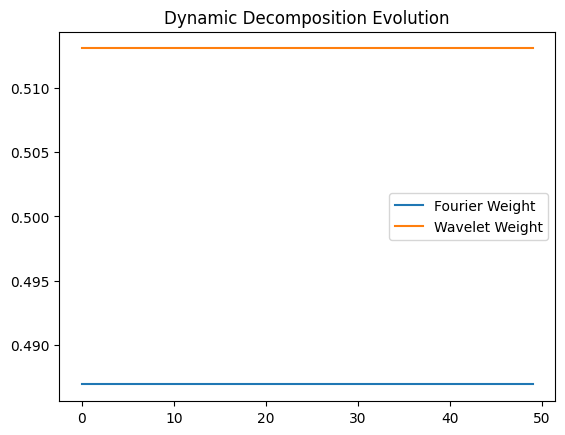

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import numpy as np
import matplotlib.pyplot as plt


class AutoCorrelation(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.period_proj = nn.Linear(feature_dim, feature_dim)

    def forward(self, x):
        batch_size, seq_len, dim = x.shape

        x_fft = torch.fft.rfft(x, dim=1)
        autocorr = torch.fft.irfft(x_fft * x_fft.conj(), n=seq_len, dim=1)

        top_vals, top_idx = torch.topk(autocorr.mean(dim=-1), k=3, dim=1)

        return top_idx, top_vals / top_vals.sum(dim=1, keepdim=True)


class DecompositionBlock(nn.Module):
    def __init__(self, seq_len, feature_dim):
        super().__init__()
        self.seq_len = seq_len
        self.feature_dim = feature_dim

        self.fourier_basis = nn.Parameter(torch.randn(seq_len, feature_dim))

        kernel_size = 7
        self.wavelet_basis = nn.Parameter(
            torch.randn(feature_dim, 1, kernel_size)
        )

        self.decomp_gate = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, 2),
            nn.Softmax(dim=-1)
        )

    def forward(self, x, periods):
        batch_size, seq_len, dim = x.shape

        fourier_series = torch.zeros_like(x)
        t = torch.arange(seq_len, device=x.device).float()

        for b in range(batch_size):
            for i, period in enumerate(periods[b]):
                freq = 2 * np.pi / (period.float() + 1.0)

                sin_comp = torch.sin(freq * t).unsqueeze(1) * self.fourier_basis
                cos_comp = torch.cos(freq * t).unsqueeze(1) * self.fourier_basis

                fourier_series[b] += (sin_comp + cos_comp) * (i + 1)

        wavelet_series = F.conv1d(
            x.transpose(1, 2),
            self.wavelet_basis,
            padding=self.wavelet_basis.size(-1) // 2,
            groups=dim
        ).transpose(1, 2)

        wavelet_series = wavelet_series[:, :seq_len, :]

        gate = self.decomp_gate(x.mean(dim=1))
        fourier_weight = gate[:, 0].view(batch_size, 1, 1)
        wavelet_weight = gate[:, 1].view(batch_size, 1, 1)

        combined = fourier_weight * fourier_series + wavelet_weight * wavelet_series

        return combined, gate


class Autoformer(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.decomposer = DecompositionBlock(
            seq_len=config['seq_len'],
            feature_dim=config['feature_dim']
        )

        self.period_detector = AutoCorrelation(config['feature_dim'])

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=config['feature_dim'],
                nhead=8,
                dim_feedforward=512,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=2
        )

        self.decoder = nn.LSTM(
            input_size=config['feature_dim'],
            hidden_size=config['feature_dim'],
            num_layers=2,
            batch_first=True
        )

        self.forecast_head = nn.Linear(
            config['feature_dim'],
            config['forecast_len']
        )

    def forward(self, x):
        periods, period_strength = self.period_detector(x)

        seasonal, decomposition_gate = self.decomposer(x, periods)

        trend = F.avg_pool1d(
            x.transpose(1, 2),
            kernel_size=7,
            stride=1,
            padding=3
        ).transpose(1, 2)

        residual = x - seasonal - trend

        encoded = self.encoder(residual)

        decoder_input = encoded + seasonal + trend

        decoded, _ = self.decoder(decoder_input)

        return self.forecast_head(decoded[:, -1, :]), decomposition_gate


config = {
    'seq_len': 144,
    'feature_dim': 32,
    'forecast_len': 12
}

model = Autoformer(config)

retail_data = torch.randn(64, 144, 32)

forecast, gate = model(retail_data)

print(f"12-month forecast shape: {forecast.shape}")
print(f"Decomposition gate (Fourier, Wavelet): {gate.mean(dim=0).detach()}")

gate_history = []

for epoch in range(50):
    _, gate = model(retail_data[:4])
    gate_history.append(gate.mean(dim=0).detach().numpy())

gate_trend = np.stack(gate_history)

plt.plot(gate_trend[:, 0], label='Fourier Weight')
plt.plot(gate_trend[:, 1], label='Wavelet Weight')
plt.title("Dynamic Decomposition Evolution")
plt.legend()
plt.savefig('autoformer_gate_evolution.png')

# 9. PatchTST: Channel-Independent Patching Transformer


In [3]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.3 MB/s eta 0:00:00
  Attempting uninstall: tornado
    Found existing installation: tornado 6.5.1
    Uninstalling tornado-6.5.1:
      Successfully uninstalled tornado-6.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is

In [8]:
import numpy as np
import pandas as pd
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MSE
import matplotlib.pyplot as plt

# Load electricity dataset
df = pd.read_csv(
    'https://raw.githubusercontent.com/Nixtla/transfer-learning-time-series/main/datasets/electricity-short.csv'
)

# Required column types
df['unique_id'] = df['unique_id'].astype(str)
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'])

# 정렬 권장
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

model = PatchTST(
    h=72,
    input_size=336,
    patch_len=24,
    stride=12,
    hidden_size=128,
    n_heads=16,
    dropout=0.2,
    loss=MSE(),
    scaler_type='standard',
    max_steps=500
)

nf = NeuralForecast(models=[model], freq='H')

nf.fit(df=df)

predictions = nf.predict()

print(predictions.head())
print(f"Sequence reduction: 336 raw points → {336//12} patches = {336//12/336:.1%} of original length")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MSE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  662 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 662 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 662 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


  unique_id                  ds   PatchTST
0        BE 2016-12-31 00:00:00  46.180817
1        BE 2016-12-31 01:00:00  45.029037
2        BE 2016-12-31 02:00:00  47.452179
3        BE 2016-12-31 03:00:00  42.657829
4        BE 2016-12-31 04:00:00  41.284084
Sequence reduction: 336 raw points → 28 patches = 8.3% of original length


# 10. Chronos: Zero-Shot Foundation Models for Time Series


In [1]:
!pip install chronos-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt

# Zero-shot scenario: New product line with only 30 days of data
# Traditional models fail here; Chronos thrives with its pre-trained knowledge

# Initialize pipeline: 710M parameter model pre-trained on 100B+ data points
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-large",
    device_map="cuda",
    torch_dtype=torch.bfloat16
)

# Load minimal historical data (cold-start problem)
df = pd.read_csv('new_product_sales.csv')
context = torch.tensor(df['sales'].values[-50:])  # Only 50 historical points

# Chronos tokenization: Real values → 4096 discrete bins
# This converts continuous values into categorical tokens like a language model
# Example: 123.45 → token_id 2847, 67.89 → token_id 1523

# Generate zero-shot probabilistic forecasts: 100 samples for uncertainty quantification
forecast = pipeline.predict(
    context=context,
    prediction_length=30,  # Forecast next 30 days
    num_samples=100,
    temperature=1.0,
    top_k=50,
    top_p=1.0
)

# forecast shape: [100, 30] = 100 sample paths, 30 days each
median = np.quantile(forecast.numpy(), 0.5, axis=0)
lower, upper = np.quantile(forecast.numpy(), [0.1, 0.9], axis=0)

# Visualize with prediction intervals
plt.plot(range(len(context)), context, label='Historical')
plt.plot(range(len(context), len(context)+30), median, label='Median Forecast')
plt.fill_between(range(len(context), len(context)+30), lower, upper, alpha=0.3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

FileNotFoundError: [Errno 2] No such file or directory: 'new_product_sales.csv'